# 0. Setup Python

In [206]:
#First of all, let's import all the necessary libraries and check the versions to ensure compatibility.
#We will follow what what recommended by the professor 
# i used those command in the terminal to set up the environment for this project :
#python -m pip install --upgrade pip
#python -m pip install uv
# uv init
# then uv add scikit-learn numpy pandas matplotlib packaging ipykernel
#to create a .venv folder and the pyproject.toml file

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 12)

# Scikit-Learn ≥1.8.0 is required
import sklearn
assert sklearn.__version__ >= "1.8.0"
print(sklearn.__version__)

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

1.8.0


# 1. Look at the Big Picture

What do we want to achieve ?

We want to predict the ratio of people attending a lesson. We will base our research on the data of an backup and also during the examen, try to predict one ratio, based on data given in the *lessen-groep.csv*

This a problem of supervised learning:  our label will be "aanwezigheidsgraad", which is the ratio between userCount/totalStudents which

This is then a Regression Problem because we want to predict a numerical value.


# 2. Extract Data

Now, we will import the data from the database in order to analyse the data.

They were stored in a backup and were opened with SQL SERVER 2022.

Here is the query SQL i used tro fetch the data :

In [69]:
SELECT 
f.DateKey AS [date], 

f.FromTimeKey AS [from], 

f.UntilTimeKey AS [until], 

a.CanonicalActivity AS activity,

s.SubgroupCode AS subgroup, 

s.ProgramName AS program, 

r.RoomFloor AS [floor], 

r.Category AS roomcategory, 

r.Capacity AS capacity, 

r.Area AS area, 

c.ClassCredits AS credits,

f.UserCount as usercount,
    
f.TotalStudents as totalstudents

FROM 
    dbo.FactLecture f

INNER JOIN 
    dbo.DimActivity a ON f.ActivityKey = a.ActivityKey

INNER JOIN 
    dbo.DimSubgroup s ON f.SubgroupKey = s.SubgroupKey

INNER JOIN 
    dbo.DimRoom r ON f.RoomKey = r.RoomKey
    
INNER JOIN 
    dbo.DimClass c ON f.ClassKey = c.ClassKey;

SyntaxError: invalid syntax (472580494.py, line 2)

In [293]:


csv_path = 'aanwezigheden_project.csv'

df = pd.read_csv(csv_path, sep=None, engine='python')
df.head(10)





,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits,usercount,totalstudents
0,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,5.0,20
1,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,7.0,17
2,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,4.0,21
3,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,2.0,21
4,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,1.0,21
5,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,8.0,20
6,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,7.0,17
7,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,5.0,21
8,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,7.0,21
9,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,2.0,21


In [295]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ﻿date          18499 non-null  int64  
 1   from           18499 non-null  int64  
 2   until          18499 non-null  int64  
 3   activity       18499 non-null  str    
 4   subgroup       18499 non-null  str    
 5   program        18499 non-null  str    
 6   floor          18499 non-null  int64  
 7   roomcategory   18499 non-null  str    
 8   capacity       18499 non-null  int64  
 9   area           18499 non-null  float64
 10  credits        18499 non-null  int64  
 11  usercount      6977 non-null   float64
 12  totalstudents  18499 non-null  int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 1.8 MB


We have 6977 record for usercount different from NULL.
Thus i took the decision to remove all the record where usercount are NULL, as userCount is the base to have the target to be predicted.

After, we will create our target to see what are the feature and attribute to keep in our model later on the section 4.

In [ ]:
#drop all the rows where 'usercount' is 0, otherwise, we will have a lot of rows with 0 students present, 
# which will skew our analysis and model training.
df = df.dropna(subset=['usercount'])

#creating our target variable 'aanwezigheidsgraad' by dividing the number of students present ('usercount') 
# by the total number of students ('totalstudents')
df['aanwezigheidsgraad'] = df['usercount'] / df['totalstudents']

#to protect data leakage !
df = df.drop(columns=['usercount', 'totalstudents'])

df.head(10)

,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits,aanwezigheidsgraad
0,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.250000
1,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.411765
2,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.190476
3,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.095238
4,20251103,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.047619
5,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1A,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.400000
6,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1A,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.411765
7,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1B,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.238095
8,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-MRT/DAG/1B,GRAD-EMS-MRT,1,laptoplokaal,90,142.48,3,0.333333
9,20251117,154500,174500,Activerend hoorcollege,GRAD-EMS-OHT/DAG/1C,GRAD-EMS-OHT,1,laptoplokaal,90,142.48,3,0.095238


In [297]:
df.info()

<class 'pandas.DataFrame'>
Index: 6977 entries, 0 to 18493
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ﻿date               6977 non-null   int64  
 1   from                6977 non-null   int64  
 2   until               6977 non-null   int64  
 3   activity            6977 non-null   str    
 4   subgroup            6977 non-null   str    
 5   program             6977 non-null   str    
 6   floor               6977 non-null   int64  
 7   roomcategory        6977 non-null   str    
 8   capacity            6977 non-null   int64  
 9   area                6977 non-null   float64
 10  credits             6977 non-null   int64  
 11  aanwezigheidsgraad  6977 non-null   float64
dtypes: float64(2), int64(6), str(4)
memory usage: 708.6 KB


# Create a test & training set

After, we should ONLY work on our test set.

In [298]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [299]:
len(train_set)

5581

In [300]:
len(test_set)

1396

In [301]:
len(train_set) + len(test_set)

6977

In [302]:
df = train_set.copy()

# 3. Discover and Visualize the Data to Gain Insights

We will first take a look to what does the data look  like to gain insight and to prepare our data cleaning and feature engineering.

<Axes: >

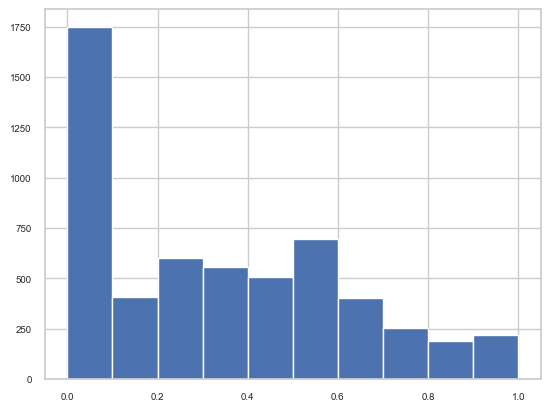

In [303]:
df["aanwezigheidsgraad"].hist()

Our aanwezigheidgraad is extremely skewed ..

In [262]:
df["aanwezigheid_cat"] = pd.cut(df["aanwezigheidsgraad"],
                               bins=[0., 0.1, 0.12, 0.15, 0.4, 0.6, 1],
                               labels=[0, 1, 12, 15, 40, 60, ])

In [263]:
df['aanwezigheid_cat'].info()

<class 'pandas.Series'>
Index: 6977 entries, 0 to 18493
Series name: aanwezigheid_cat
Non-Null Count  Dtype   
--------------  -----   
5277 non-null   category
dtypes: category(1)
memory usage: 61.4 KB


<Axes: >

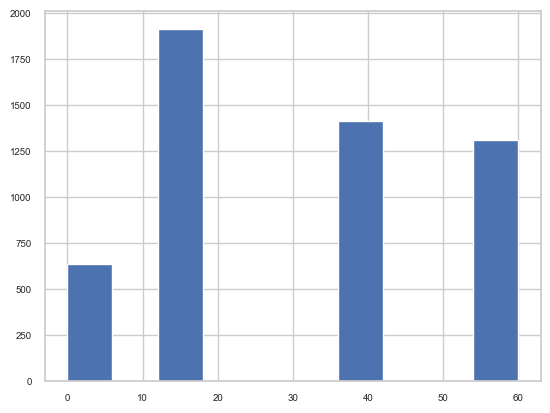

In [284]:
df['aanwezigheid_cat'].hist()

Let's start with creating some new feature before to explore deeper the data

In [ ]:
#make sure we do not have unwanted characters in the column names and remove any leading or trailing whitespace
df.columns = df.columns.str.replace('\ufeff', '').str.strip()

#feature engineering : extracting date features from the 'date' column
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
#feature engineering : extracting month and day of the week from the 'date' column
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # 0 = Maandag, 1 = Dinsdag, ..., 6 = Zondag

#feature engineering : calculating the duration of each session in hours

#because in lessen groepen we had values without second and in the SQL extract, we had values with seconds, we need to convert those values to a consistent format before calculating the duration
df['until'] = np.where(df['until'] > 9999, df['until'] // 100, df['until'])
df['from'] = np.where(df['from'] > 9999, df['from'] // 100, df['from'])

from_decimal = (df['from'] // 100) + ((df['from'] % 100) / 60)
until_decimal = (df['until'] // 100) + ((df['until'] % 100) / 60)
df['duration_hours'] = (until_decimal - from_decimal) 

df['is_morning'] = (df['from'] < 1200).astype(int)

df.head(10)

,date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits,aanwezigheidsgraad,month,day_of_week,duration_hours,is_morning
17410,2025-10-28,915,1230,Activerend hoorcollege,PBA-BM-SCM/VT/KM,PBA-BM-SCM,2,auditorium,101,125.08,4,1.000000,10,1,3.25,1
16061,2025-10-27,1800,2000,Activerend hoorcollege,PGD-SAL/1,PGD-SAL,1,leslokaal,26,58.05,6,0.142857,10,0,2.00,0
1010,2025-12-02,1030,1230,Oefensessie,PBA-VG-VG/2F1,PBA-VG-VG,1,leslokaal,26,58.05,3,0.400000,12,1,2.00,1
3795,2025-10-02,1330,1530,Activerend hoorcollege,PBA-TIN-TI/2A2,PBA-TIN-TI,4,laptoplokaal,42,88.68,5,0.000000,10,3,2.00,0
931,2025-11-12,815,1015,Activerend hoorcollege,PBA-VG-VG/2F1,PBA-VG-VG,1,auditorium,153,161.88,3,0.545455,11,2,2.00,1
2010,2025-11-14,1030,1230,Activerend hoorcollege,PBA-TIN-TI/2C1,PBA-TIN-TI,4,practicum,72,146.63,4,0.687500,11,4,2.00,1
691,2025-10-16,815,1015,Practicum,PBA-EM/1C2,PBA-EM,1,laboratorium,25,68.50,3,0.818182,10,3,2.00,1
533,2025-10-24,1030,1230,Activerend hoorcollege,PBA-EM-KL/2B,PBA-EM-KL,3,leslokaal,44,71.06,6,0.428571,10,4,2.00,1
3444,2025-11-19,1330,1530,Oefensessie,PBA-VG-LAM/1B1,PBA-VG-LAM,4,leslokaal,50,70.08,4,0.800000,11,2,2.00,0
15975,2025-12-11,1330,1430,Activerend hoorcollege,PBA-MET/2C,PBA-MET,2,laptoplokaal,24,56.02,9,0.666667,12,3,1.00,0


In [305]:
df.info()

<class 'pandas.DataFrame'>
Index: 5581 entries, 17410 to 860
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                5581 non-null   datetime64[us]
 1   from                5581 non-null   int64         
 2   until               5581 non-null   int64         
 3   activity            5581 non-null   str           
 4   subgroup            5581 non-null   str           
 5   program             5581 non-null   str           
 6   floor               5581 non-null   int64         
 7   roomcategory        5581 non-null   str           
 8   capacity            5581 non-null   int64         
 9   area                5581 non-null   float64       
 10  credits             5581 non-null   int64         
 11  aanwezigheidsgraad  5581 non-null   float64       
 12  month               5581 non-null   int32         
 13  day_of_week         5581 non-null   int32         
 14  durat

we have 4 strings column. We should make a value count on them to know what are the different possibilities of those enum :

In [306]:
df["activity"].value_counts()

activity
Activerend hoorcollege       4581
Oefensessie                   646
Practicum                     138
Onderwijsleergesprek           68
Begeleiding                    47
Examen (vaardigheidstest)      36
Stage                          15
Werkplekleren                  14
Examen (schriftelijk)          13
Examen (digitaal)               9
Werken aan opdracht             9
Examen (mondeling)              3
Presentatie (examen)            2
Name: count, dtype: int64

In [307]:
PercentHoorcollege = ((df["activity"] == "Activerend hoorcollege").sum() / len(df["activity"]))
print(PercentHoorcollege)

0.8208206414621035


80 % of the activities are Activerend hoorcollege !

There is also a lot of different type of examen. We should group them into the label examen only

In [308]:
len(df["activity"])

5581

In [309]:
df["subgroup"].value_counts()

subgroup
PBA-TIN-TI/VT/NET/S1     235
PBA-TIN-TI/VT/PROG/S1    174
PBA-TIN-TI/1H            113
PBA-TIN-TI/2C1           110
PBA-TIN-TI/2A2            97
                        ... 
PBA-BMLT-MLT/3A            1
GRAD-EMS-OHT/DAG/2B2       1
PBA-SW/1A4                 1
GRAD-HVAC/1D2              1
GRAD-HVAC/1B               1
Name: count, Length: 426, dtype: int64

We can see that there is too many possibilities ! 

So why not just keep the program column ?

Probably a good idea :)

In [310]:
df["program"].value_counts()

program
PBA-TIN-TI       1854
PBA-VG-VG         372
PBA-BM-MK         369
PBA-VG-LAM        344
PBA-BM-KM         283
                 ... 
MC-SCH              3
PBA-EM-AM           2
PBA-BM-FV           2
PBA-LA-LO           2
PBA-AGR-GM-GM       2
Name: count, Length: 70, dtype: int64

In [311]:
df["roomcategory"].value_counts()     

roomcategory
laptoplokaal    2133
leslokaal       1447
auditorium      1335
PC-klas          374
practicum        214
laboratorium      76
vergaderzaal       2
Name: count, dtype: int64

In [312]:
df.describe()

,date,from,until,floor,capacity,area,credits,aanwezigheidsgraad,month,day_of_week,duration_hours
count,5581,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000,5581.000000
mean,2025-11-05 05:50:23.329152,1155.328794,1375.989966,2.252285,76.797527,108.988414,4.203906,0.330350,10.673535,1.997491,2.220122
min,2025-09-25 00:00:00,800.000000,915.000000,0.000000,14.000000,46.260000,1.000000,0.000000,9.000000,0.000000,1.000000
25%,2025-10-15 00:00:00,915.000000,1230.000000,1.000000,35.000000,68.500000,3.000000,0.028571,10.000000,1.000000,2.000000
50%,2025-11-04 00:00:00,1030.000000,1230.000000,2.000000,54.000000,94.260000,4.000000,0.307692,11.000000,2.000000,2.000000
75%,2025-11-26 00:00:00,1330.000000,1530.000000,3.000000,90.000000,128.050000,5.000000,0.538462,11.000000,3.000000,2.000000
max,2025-12-18 00:00:00,2030.000000,2200.000000,4.000000,381.000000,363.730000,20.000000,1.000000,12.000000,5.000000,10.000000
std,NaN,289.264384,303.118146,1.231660,78.408620,69.052616,1.535246,0.287466,0.891133,1.408625,0.756123


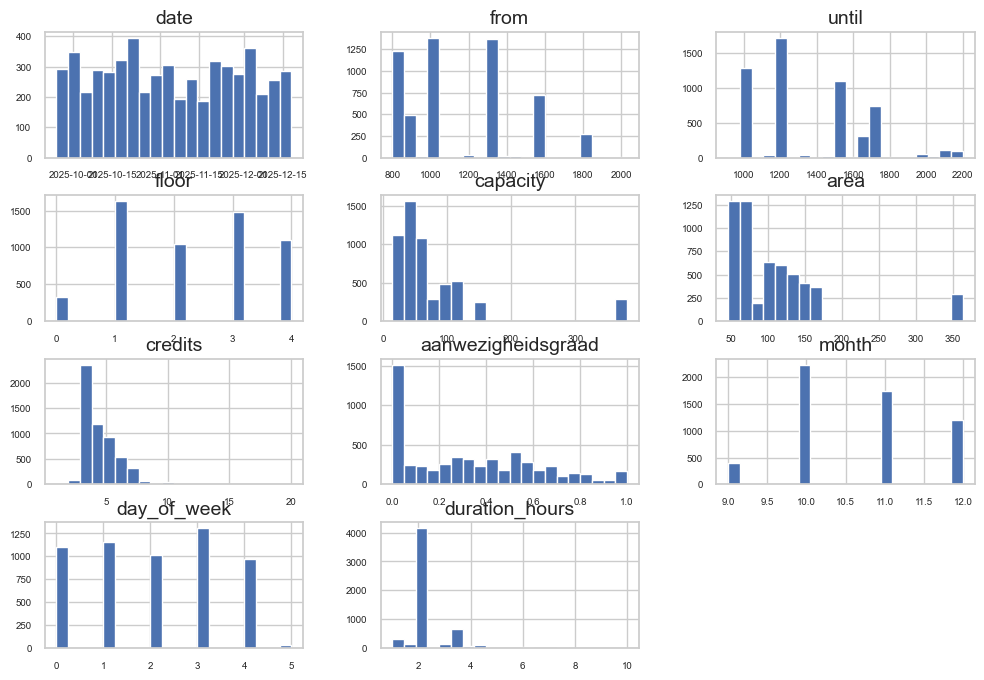

In [313]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)

df.hist(bins=20, figsize=(12, 8))
plt.show()

array([[<Axes: xlabel='day_of_week', ylabel='day_of_week'>,
        <Axes: xlabel='month', ylabel='day_of_week'>,
        <Axes: xlabel='duration_hours', ylabel='day_of_week'>,
        <Axes: xlabel='capacity', ylabel='day_of_week'>,
        <Axes: xlabel='area', ylabel='day_of_week'>,
        <Axes: xlabel='credits', ylabel='day_of_week'>,
        <Axes: xlabel='aanwezigheidsgraad', ylabel='day_of_week'>],
       [<Axes: xlabel='day_of_week', ylabel='month'>,
        <Axes: xlabel='month', ylabel='month'>,
        <Axes: xlabel='duration_hours', ylabel='month'>,
        <Axes: xlabel='capacity', ylabel='month'>,
        <Axes: xlabel='area', ylabel='month'>,
        <Axes: xlabel='credits', ylabel='month'>,
        <Axes: xlabel='aanwezigheidsgraad', ylabel='month'>],
       [<Axes: xlabel='day_of_week', ylabel='duration_hours'>,
        <Axes: xlabel='month', ylabel='duration_hours'>,
        <Axes: xlabel='duration_hours', ylabel='duration_hours'>,
        <Axes: xlabel='capacity', 

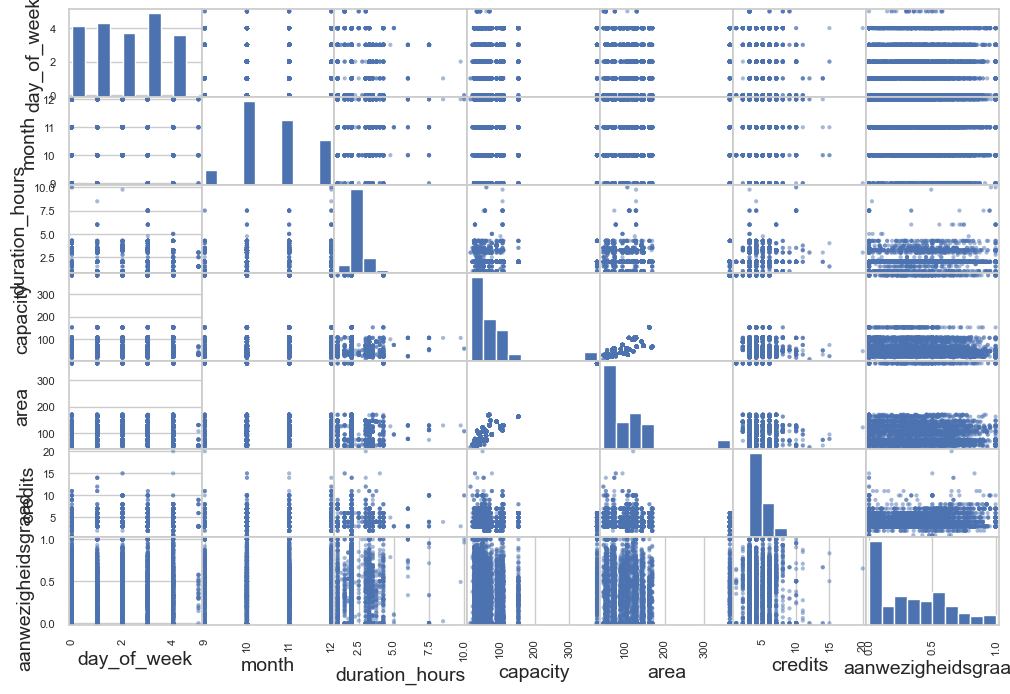

In [318]:
from pandas.plotting import scatter_matrix

attributes = [ "day_of_week","month","duration_hours",
              "capacity","area","credits","aanwezigheidsgraad"]
scatter_matrix(df[attributes], figsize=(12, 8))

we can see that there is a kind of correlation between area & capacity. Nice to see that physics is well respected in this dataset.

Text(0.5, 0, 'aanwezigheidsgraad')

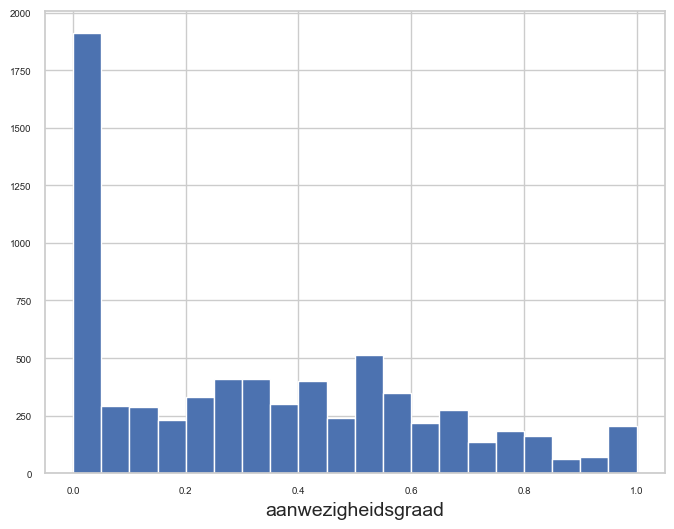

In [273]:
df['aanwezigheidsgraad'].hist(bins=20, figsize=(8, 6))
plt.xlabel('aanwezigheidsgraad')

In [274]:
df['aanwezigheidsgraad'].describe()

count    6977.000000
mean        0.328417
std         0.287025
min         0.000000
25%         0.026316
50%         0.306122
75%         0.533333
max         1.000000
Name: aanwezigheidsgraad, dtype: float64

Our aanwezigheidsgraad is right skewed. It means most of the lesson have few people attending it.

Would it be possible that is due to error in the way we collected the data ?

KeyError: 'month'

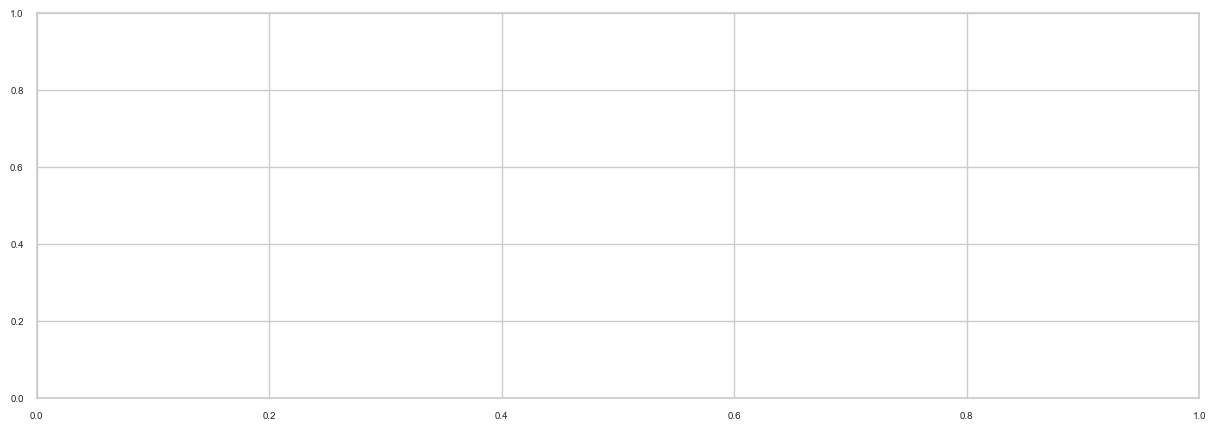

In [290]:
plt.subplots(figsize=(15,5))
plt.plot(df['month'],df['aanwezigheidsgraad'],'b.')
plt.xlabel("month")
plt.ylabel("aanwezigheidsgraad")

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# On groupe par mois et on calcule la moyenne de présence
moyenne_par_mois = train_set.groupby('month')['aanwezigheidsgraad'].mean().reset_index()

sns.lineplot(data=moyenne_par_mois, x='month', y='aanwezigheidsgraad', marker='o', color='b', linewidth=2)
plt.title("Évolution de la présence moyenne par mois", fontsize=14)
plt.xlabel("Mois de l'année")
plt.ylabel("Taux de présence moyen")
plt.ylim(0, 1) # L'axe Y va de 0% à 100%
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

KeyError: 'month'

<Figure size 1000x500 with 0 Axes>

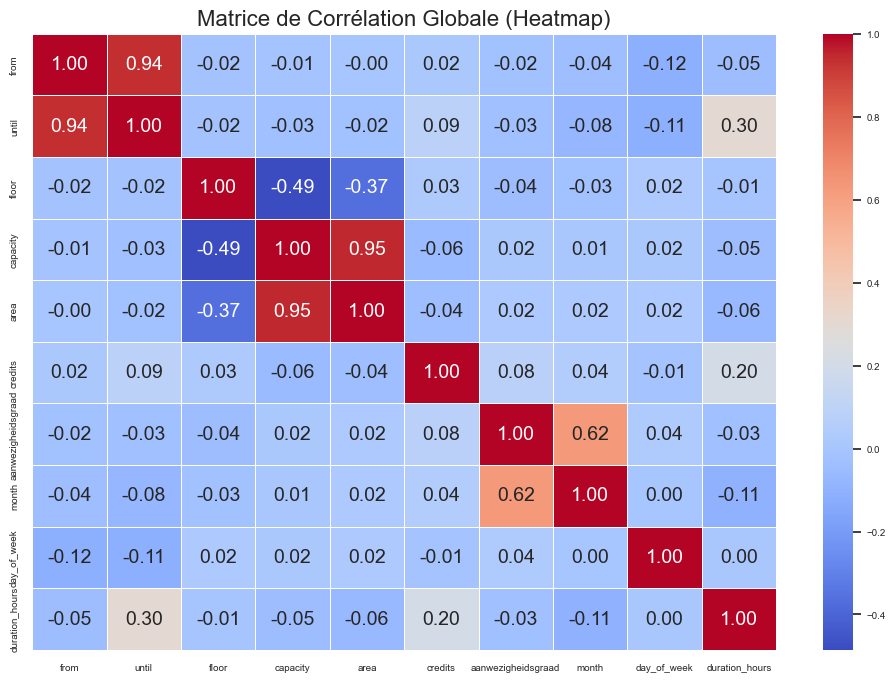

In [191]:
# 1. Sécurité : On ne garde QUE les colonnes numériques (sinon le calcul plante sur du texte)
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64', 'int32'])

# 2. Calcul de la matrice de corrélation
matrice_corr = colonnes_numeriques.corr()

# 3. Configuration et affichage du graphique (Heatmap)
plt.figure(figsize=(12, 8)) # On met une bonne taille pour que ce soit lisible

# Paramètres :
# annot=True : Affiche les chiffres dans les cases
# cmap='coolwarm' : Met du bleu pour le négatif et du rouge pour le positif
# fmt=".2f" : Arrondit à 2 chiffres après la virgule
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation Globale (Heatmap)", fontsize=16)
plt.show()

The most correlatade feature with the aanwezigheidgraad is the month.

WHAT OTHER PLOT & FEATURE ENGINEERING COULD WE PERFORM ?

In [192]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["aanwezigheidsgraad"].sort_values(ascending=False)

aanwezigheidsgraad    1.000000
month                 0.624817
credits               0.078017
day_of_week           0.035029
area                  0.020692
capacity              0.016357
from                 -0.022400
duration_hours       -0.029176
until                -0.031795
floor                -0.044703
Name: aanwezigheidsgraad, dtype: float64

Interesting things to see here :

inverse correlation between aanwezigheidgraad and date :)

we should do better feature engineering on those

# 4. Prepare the Data for Machine Learning Algorithms

In [291]:
df = train_set.drop("aanwezigheidsgraad", axis=1) # drop labels for training set
df_labels = train_set["aanwezigheidsgraad"].copy()

In [292]:
df.head()

,﻿date,from,until,activity,subgroup,program,floor,roomcategory,capacity,area,credits
17410,20251028,91500,123000,Activerend hoorcollege,PBA-BM-SCM/VT/KM,PBA-BM-SCM,2,auditorium,101,125.08,4
16061,20251027,180000,200000,Activerend hoorcollege,PGD-SAL/1,PGD-SAL,1,leslokaal,26,58.05,6
1010,20251202,103000,123000,Oefensessie,PBA-VG-VG/2F1,PBA-VG-VG,1,leslokaal,26,58.05,3
3795,20251002,133000,153000,Activerend hoorcollege,PBA-TIN-TI/2A2,PBA-TIN-TI,4,laptoplokaal,42,88.68,5
931,20251112,81500,101500,Activerend hoorcollege,PBA-VG-VG/2F1,PBA-VG-VG,1,auditorium,153,161.88,3


we group all different name of examen

In [276]:
def groepeer_activiteit(activiteit):
    # On transforme le texte en minuscules juste pour la vérification
    # ex: "Presentatie (examen)" reste "presentatie (examen)"
    # ex: "Examen (digitaal)" devient "examen (digitaal)"
    activiteit_min = activiteit.lower()
    
    # Maintenant on cherche 'examen' tout en minuscules !
    if 'examen' in activiteit_min:
        return 'Examen'
    elif activiteit == 'Activerend hoorcollege':
        return 'Activerend hoorcollege'
    elif activiteit == 'Oefensessie':
        return 'Oefensessie'
    elif activiteit == 'Practicum':
        return 'Practicum'
    else:
        return 'Andere'

# On applique la fonction
df['activity'] = df['activity'].apply(groepeer_activiteit)

# On vérifie le résultat
print(df['activity'].value_counts())

activity
Activerend hoorcollege    5722
Oefensessie                810
Andere                     189
Practicum                  169
Examen                      87
Name: count, dtype: int64


let's drop the subgroup column because this is not really relevant as we have the program column.

In [277]:
df.drop(columns=['subgroup'], inplace=True)

perform also :

encoding ?

creating new attribute / feature engineering ?

Feature Scaling

Custom Transformers ?? qu'est ce que c'est ?

In [182]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["aanwezigheidsgraad"].sort_values(ascending=False)

aanwezigheidsgraad    1.000000
month                 0.624817
credits               0.078017
day_of_week           0.035029
area                  0.020692
capacity              0.016357
from                 -0.022400
duration_hours       -0.029176
until                -0.031795
floor                -0.044703
Name: aanwezigheidsgraad, dtype: float64

let's plot correlation plot between aanweizgheidgraad and month, floor, duration hours & credits

C:\Users\Azzah\AppData\Local\Temp\ipykernel_46228\1245599072.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


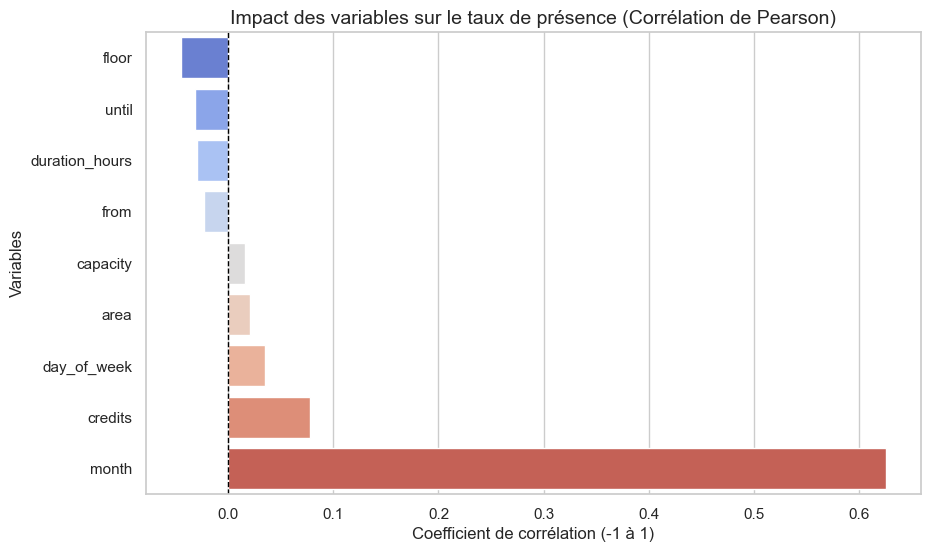

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On calcule les corrélations uniquement avec la cible, on enlève la cible elle-même (qui est à 1.0) et on trie
corr_with_target = df.select_dtypes(include=['number']).corr()['aanwezigheidsgraad'].drop('aanwezigheidsgraad').sort_values()

# 2. On crée un beau graphique à barres horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')

# 3. On ajoute les titres et légendes
plt.title("Impact des variables sur le taux de présence (Corrélation de Pearson)", fontsize=14)
plt.xlabel("Coefficient de corrélation (-1 à 1)")
plt.ylabel("Variables")

# On ajoute une ligne verticale à 0 pour bien voir le positif vs négatif
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.show()

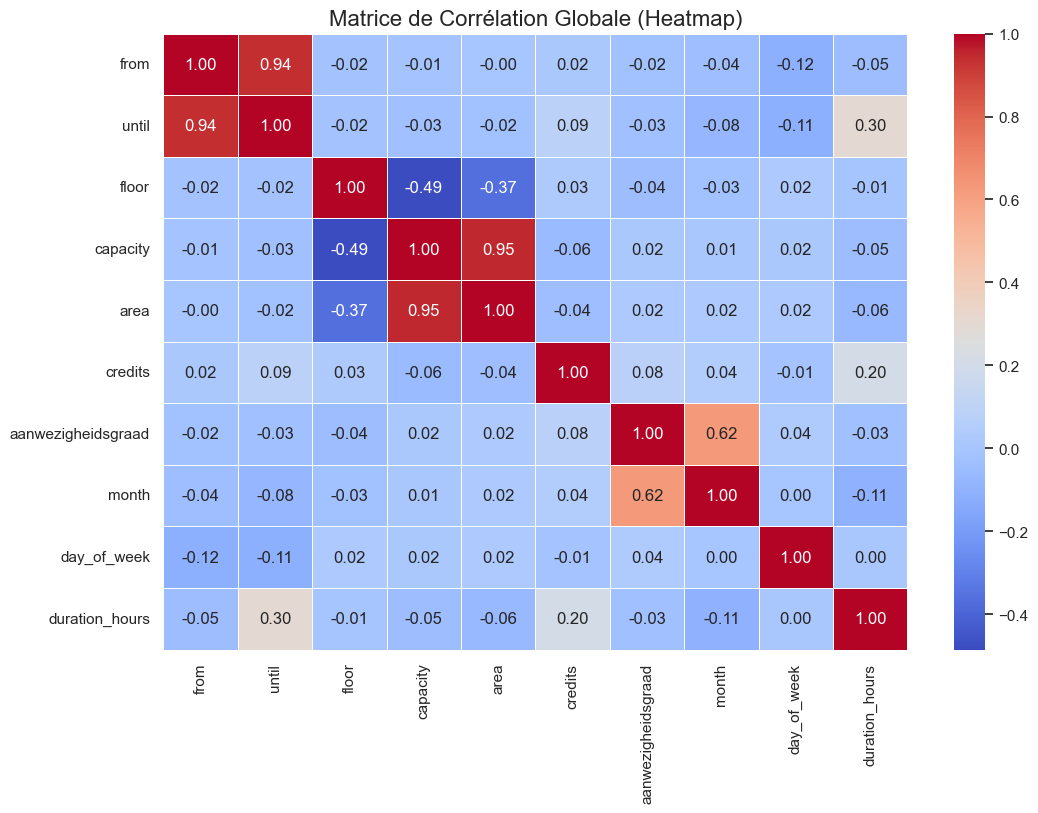

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sécurité : On ne garde QUE les colonnes numériques (sinon le calcul plante sur du texte)
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64'])

# 2. Calcul de la matrice de corrélation
matrice_corr = colonnes_numeriques.corr()

# 3. Configuration et affichage du graphique (Heatmap)
plt.figure(figsize=(12, 8)) # On met une bonne taille pour que ce soit lisible

# Paramètres :
# annot=True : Affiche les chiffres dans les cases
# cmap='coolwarm' : Met du bleu pour le négatif et du rouge pour le positif
# fmt=".2f" : Arrondit à 2 chiffres après la virgule
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation Globale (Heatmap)", fontsize=16)
plt.show()

### Handling Text and Categorical Attributes

for instance : program, roomcategory ? activity ? => what to do with them ? encoding etc ? 

# 5. Select and Train a Model

# 6. Fine-Tune Your Model

# 7. Launch, monitor, and maintain your system.